# ISYE6240: Homework 2

## Question 1

### 1a)

If  $f(x) = \frac{3x^2}{16} \quad where -2<x<2$
Then for evaluating $|X|<0.5$:
$$P(-0.5 < X < 0.5) = \int_{-0.5}^{0.5} f(x)dx = \int_{-0.5}^{0.5}\frac{3x^2}{16}dx$$
$$\left. P(-0.5 < X < 0.5)=\frac{x^3}{16} \right|_{-0.5}^{0.5} = \frac{1}{128}-(-\frac{1}{128})=\frac{1}{64}$$

### 1b)

The Cumulative Distribution Function is the integral of the PDF from it's lower limit to some point between the limits.
$$F(x) = \int_{-2}^{x} \frac{3t^2}{16} dt = \left[ \frac{t^3}{16} \right]_{-2}^{x} = \frac{x^3}{16} - \frac{(-2)^3}{16} = \frac{x^3 + 8}{16}$$

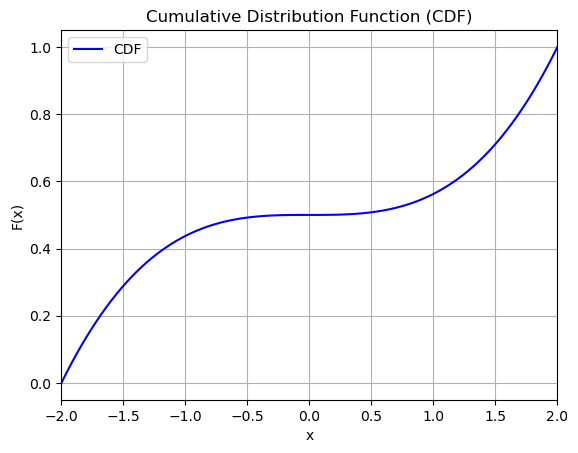

In [1]:
import matplotlib.pyplot as plt
# Plot CDF
limits = [-2, 2]
function = lambda x: ((x**3)+8)/16

def plot_cdf(func, x_limits, num_points=100):
    x = [x_limits[0] + i * (x_limits[1] - x_limits[0]) / (num_points - 1) for i in range(num_points)]
    y = [func(xi) for xi in x]

    plt.plot(x, y, label='CDF', color='blue')
    plt.title('Cumulative Distribution Function (CDF)')
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.xlim(x_limits)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_cdf(function, limits)

### 1c)

The Expectation (the mean in this context) is calculated as
$$E(x) = \int x.f(x)dx$$
In the case where expectation $Y=X^2$ then:
$$
EX = \int_{-2}^{2} x^2.f(x)dx = \int_{-2}^{2}\frac{3x^4}{16}
$$
$$
EX = \left. \frac{3x^5}{80} \right|_{-2}^{2} = \frac{96}{80} - (-\frac{96}{80})= \frac{12}{5} = 2.4
$$

Hence, the mean loss is $2400.

### 1d)

In the case of a loss being <4000, 
$Y=X^2$ = 4 so $X= \pm 2$

As these are the limits for out distribution, the maximum loss that can occur is $4000. Hence, the probability of loss being <4000 is 1.


## Question 2

### 2a)

MLE for the rate parameter (lambda) of the exponential distribution: 0.99


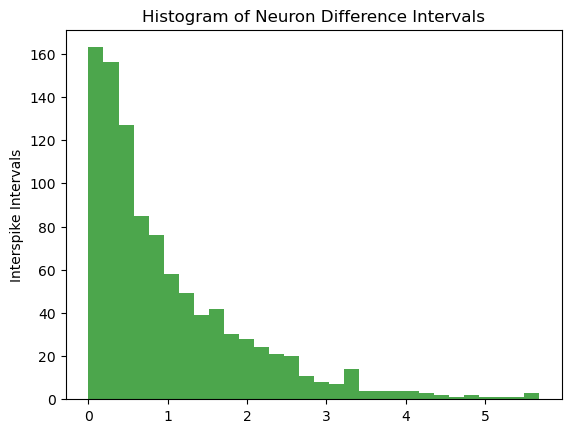

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Import CSV data and plot histogram
data = pd.read_csv('../../data/neurondiffs.csv')
plt.hist(data, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Neuron Difference Intervals')
plt.ylabel("Interspike Intervals")

# Calculate the MLE for the rate parameter of an exponential distribution
interspike_intervals = data['value']
mle_rate = 1 / interspike_intervals.mean()
print(f"MLE for the rate parameter (lambda) of the exponential distribution: {round(mle_rate, 3)}")

The histogram of interspike intervals resembles an exponential distribution. Computing the MLE for the rate parameter is derived from finding the maximum of the likelihood function, which results in: $$\hat{\lambda}_{MLE} = \frac{1}{\bar{T}} = \frac{n}{\sum T_i} = 0.99$$

where ${\bar{T}}$ is the sample mean.

Running this for the neurondiffs data produces and MLE of 0.99. For an exponential distribution if $\lambda \approx 1$, then the mean and standard deviation are approximately equal (with a value of approximately 1)



### 2b)
If the prior is $\lambda \sim \text{Gamma}(\alpha=18, \beta=20)$, and we know for our data (likelihood) we have the $\lambda_{data} = \lambda_{MLE} \approx 1$

We can utilise the kernel method, as in the conjugate family the posterior density is proportional to the likelihood and prior densities multiplied. 
$$P(\lambda | T) \propto L(\lambda) \times \pi(\lambda)$$
The likelihood is the joint distribution of the PDFs.

$$L(\lambda) = \prod_{i=1}^{n} \lambda e^{-\lambda T_i} = \lambda^n e^{-\lambda \sum T_i}$$
The Prior which is a Gamma distribution:
$$\pi(\lambda) \propto \lambda^{\alpha-1} e^{-\beta \lambda}$$
$$
P(\lambda|T) \propto \lambda^{\alpha-1+n}e^{-\lambda(\beta+\sum T_i)}
$$
Comparing with the intended form of the posterior distribution we can see the change from the prior as:
$\alpha_{post} = \alpha+n$ and $\beta_{post} = \beta + \sum T_i$

We can find $\sum T_i$ as it's in the equation for $\lambda_{MLE} = \frac{n}{\sum T_i}$. Hence $\sum T_i = \frac{988}{0.99} \approx 997.98$
Therefore, the Bayes estimator (posterior mean) is:
$$
E(\lambda|T) = \frac{\alpha+n}{\beta + \sum T_i} = \frac{18+988}{20 + 997.98} \approx 0.988
$$
The posterior variance is:
$$
Var(\lambda|T) = \frac{\alpha_{post}}{\beta_{post}^2} = \frac{\alpha+n}{(\beta+\sum T_i)^2} \approx \frac{1006}{1017.98^2} \approx 0.00097
$$

### 2c)
If $\mu = \frac{1}{\lambda}$ and we want $P(\mu|T)$, then our new likelihood and prior are the following:
$$
L(\mu) = \mu^{-n}e^{\frac{-\sum T_i}{\mu}}
$$
$$
\pi(\mu) \propto \mu^{-(a+1)}e^{\frac{b}{\mu}}
$$
derived from the Inverse Gamma distribution of $\mu$.

Using the Bayes Theorem for conjugate families as we did before: 
$P(\mu | T) \propto L(\mu)\pi(\mu)$
$$
P(\mu|T) \propto \mu^{-(a+1)-n}e^{\frac{b}{\mu}-\frac{-\sum T_i}{\mu}} = \mu^{-(a+1+n)}e^{-\frac{1}{\mu}(b + \sum T_i)}
$$
$$
a_{post} = a+n,\ b_{post} = b +\sum T_i
$$
We can now calculate posterior mean for posterior $\mu$ which also follows an inverse gamma distribution.
$$
E(\mu|T) = \frac{b_{post}}{a_{post}-1} = \frac{b +\sum T_i}{a+n-1} = \frac{20+997.98}{18+988-1} \approx 1.01
$$



## Question 3

### 3a)
Marginal Posterior Distribution for a conjugate case:
$$
P(\theta_1|y) \propto {P(y|\theta_1).P(\theta_1)}
$$

The posterior for $\theta$ can be calculated as we know the Normal-Normal conjugate family above so our posterior is also a normal distribution
$$
P(\theta \mid \text{data}) = \frac{P(\text{data} \mid \theta) P(\theta)}{P(\text{data})}$$
For conjugate family of normal-normal distributions:
$$
P(\theta_1|y) \propto {P(y|\theta_1).P(\theta_1)}
$$
$$\text{Posterior} \propto \exp \left( -\frac{(x-\theta)^2}{2\sigma^2} - \frac{(\theta-\mu)^2}{2\tau^2} \right)$$
The known formulas for calculating Posterior Mean and Posterior Variance are:
$$\mu_{post}= \frac{\tau^2}{\sigma^2 + \tau^2}y + \frac{\sigma^2}{\sigma^2 + \tau^2}\mu$$
$$\tau_{post}^2 = \frac{\sigma^2 \tau^2}{\sigma^2 + \tau^2}$$
In this context:
$$
Prior \ on \ \theta_i: N(\mu,\sigma) = N(0,1)
$$
$$
Likelihood: N(\phi,\tau) = N(\theta_1 + \theta_2,1)
$$
Prior for $\theta_1 + \theta_2$ involves combining the two distributions. Combining two identical normal distributions is simply adding the means and variances, hence for $\phi = \theta_1 + \theta_2$:
$$
Prior \ on \ \phi: N(\mu,\sigma) = N(0,2)
$$
This now allows us to use the above equations to calculate posterior mean and variance, when y=1:
$$\mu_{post}= \frac{2}{2 + 1}y + \frac{1}{2 + 1}(0) = \frac{2}{3}y = \frac{2}{3}$$
$$\tau^2_{post}= \frac{2*1}{2 + 1} = \frac{2}{3}$$


As $\theta_1$ and $\theta_2$ have identical $iid$ priors and enter the likelihood symmetrically, their marginal posterior distributions are identical: $E[\theta_1 \mid y] = E[\theta_2 \mid y]$. Hence the posterior mean must be the sum of the individual means:
$$E[\theta_1 + \theta_2 \mid y] = E[\theta_1 \mid y] + E[\theta_2 \mid y] = 2/3$$
$$
E[\theta_1 \mid y] = E[\theta_2 \mid y] = 1/3
$$

Finding the marginal variance is more tricky,
Since $y$ is normally distributed with mean $\theta_1 + \theta_2$ and variance $1$, we can represent it as a linear equation:

$$y = \theta_1 + \theta_2 + \epsilon$$

where $\epsilon \sim N(0,1)$ represents the random noise and is independent to the other components.

We can use precision to calculate it where precision $w$ for $\theta_1$: $w=\frac{1}{\sigma^2}$
To find the posterior precision for $\theta_1$, we sum the prior precision of $\theta_1$ and the precision provided by the data ($y$). 
$$
w_{post} = w_{prior} + w_{data} = 1 + \frac{1}{1+1} = \frac{3}{2}
$$
To find the posterior variance:
$$
\tau^2_{post} = \frac{1}{w} = \frac{2}{3}
$$
Finally:
$$
\theta_1|y \sim N(\frac{1}{3},\frac{2}{3})
$$
$$
\theta_2|y \sim N(\frac{1}{3},\frac{2}{3})
$$

### 3b)

For the posterior distribution of $\theta_1 - \theta_2$ we can first find the prior:
As $\theta_1$ and $\theta_2$ are independent the combined mean and variance are simple to calculate, as we can remove the covariate term.
$$Var(a\theta_1 + b\theta_2) = a^2 Var(\theta_1) + b^2 Var(\theta_2)$$
If we say $D=\theta_1 - \theta_2$:
$$D \sim N(0, 1+1) \implies D \sim N(0, 2)$$
We know the likelihood is: $$y | \theta_1, \theta_2 \sim N(\theta_1 + \theta_2, 1) \implies N(S, 1)$$
So the likelihood is only dependent on S = $\theta_1+\theta_2$, where S is also independent of D as both are made up of independent components $\theta_1, \theta_2$ and as such we expect $Cov(\theta_1, \theta_2) = 0$. This can be proven with the covariance of linear combinations rule:
$$Cov(\theta_1 + \theta_2, \theta_1 - \theta_2) = Cov(\theta_1, \theta_1) + Cov(\theta_1, -\theta_2) + Cov(\theta_2, \theta_1) + Cov(\theta_2, -\theta_2)$$
$$Cov(S, D) = Var(\theta_1) - Cov(\theta_1, \theta_2) + Cov(\theta_2, \theta_1) - Var(\theta_2)$$
$$Cov(S, D) = 1 - 0 + 0 - 1 = 0$$
Thus we have shown that *S* and *D* are independent, so the likelihood is also independent of *D*. Hence the posterior of *D* is only dependent on the prior which we already know: